## Pearson correlation of TF activity between human and mouse sample, based on mouse-trained model

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import scipy
import scipy.sparse as sparse

from scipy.stats import pearsonr

In [2]:
def process_adatas(adata1, adata2):
    adata1 = adata1.copy()
    adata2 = adata2.copy()
    
    adata1.var_names = [x.upper() for x in adata1.var_names]
    adata2.var_names = [x.upper() for x in adata2.var_names]
    common_genes = adata1.var_names.intersection(adata2.var_names)
    print(f"Found {len(common_genes)} common genes")
    adata1_common = adata1[:, common_genes]
    adata2_common = adata2[:, common_genes]
    
    return adata1_common, adata2_common

def calculate_celltype_means(adata):
    expr_df = pd.DataFrame(
        adata.X.todense() if scipy.sparse.issparse(adata.X) else adata.X,
        index=adata.obs_names,
        columns=adata.var_names
    )
    expr_df['cell_type'] = adata.obs['cell_type']
    mean_df = expr_df.groupby('cell_type').mean()
    return mean_df

def calculate_correlations(mean_df1, mean_df2):
    common_celltypes = mean_df1.index.intersection(mean_df2.index)
    mean_df1 = mean_df1.loc[common_celltypes]
    mean_df2 = mean_df2.loc[common_celltypes]
    
    common_genes = mean_df1.columns.intersection(mean_df2.columns)
    mean_df1 = mean_df1[common_genes]
    mean_df2 = mean_df2[common_genes]
    
    # calculate each TF correlation
    correlations = []
    for gene in common_genes:
        r,_ = pearsonr(mean_df1[gene], mean_df2[gene])
        correlations.append(r)
    return pd.Series(correlations, index=common_genes), common_celltypes

Found 677 common genes
Calculated correlations for 677 genes
Based on 20 common cell types


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


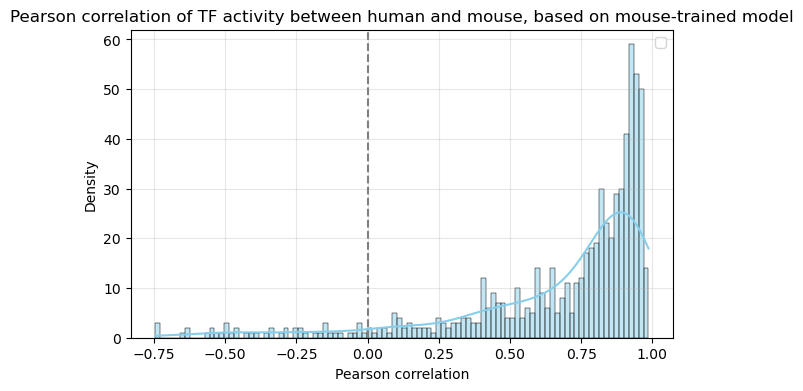

In [3]:
mmact = sc.read_h5ad('./activity_out/Mmodel_M_tfactivity.h5ad')
mhact = sc.read_h5ad('./activity_out/Mmodel_m1d1_tfactivity.h5ad')

# 1. extract common motifs
adata1_common, adata2_common = process_adatas(mmact, mhact)

# 2. calculate mean TF activity in each cell types
mean_df1 = calculate_celltype_means(adata1_common)
mean_df2 = calculate_celltype_means(adata2_common)

# 3. 计算基因相关性
correlation_series, common_celltypes = calculate_correlations(mean_df1, mean_df2)

print(f"Calculated correlations for {len(correlation_series)} genes")
print(f"Based on {len(common_celltypes)} common cell types")

# 4. 绘制相关性分布
plt.figure(figsize=(7, 4))
sns.histplot(correlation_series.values.flatten(), bins=100, kde=True, color='skyblue')
# plt.axvline(x=correlation_series.values.flatten().mean(), color='red', linestyle='--', 
#             label=f'Mean: {correlation_series.values.flatten().mean():.2f}'
#            )
plt.axvline(x=0, color='grey', linestyle='--', 
            label=None
           )
plt.xlabel('Pearson correlation')
plt.ylabel('Density')
plt.title('Pearson correlation of TF activity between human and mouse, based on mouse-trained model')
plt.legend()
plt.grid(alpha=0.3)
# plt.savefig(f'{fig_out}/corr_HMtfactivity_basedMmodel.pdf', bbox_inches='tight', dpi=300,format="pdf")
plt.show()